In [19]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

$$
G(s)=\frac{1}{s(s+B)}=\frac{1}{s^2+0.5s}
$$

In [20]:
def Gs(B):
    return ctrl.TransferFunction([1], [1, B, 0])

# Parte A - Analisis de Sensibilidad y Robustez

### a.

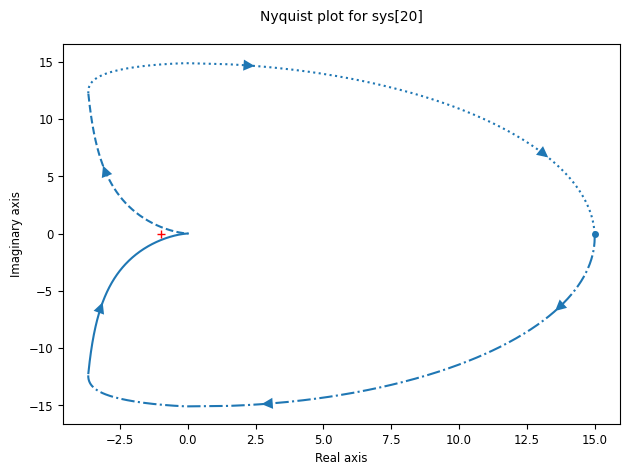

In [21]:
G = Gs(0.5)

# Diagrama de Nyquist
plt.figure()
ctrl.nyquist_plot(G)
plt.title('')
plt.grid()
plt.show()

$$
Z = N + P
$$

Donde:

$$
N = 0
\quad\text{(ninguna vuelta alrededor de }(-1,0)\text{)}
$$

$$
P = 0
\quad\text{(}G(s)\text{ no tiene polos en el semiplano derecho estricto}
$$

Por lo tanto:

$$
Z = 0 + 0 = 0
$$

Conclusión: el sistema en lazo cerrado es estable con B = 0.5.

### b.

/home/juan/miniforge3/lib/python3.12/site-packages/control/timeresp.py:1088: UserWarning: Non-zero initial condition given for transfer function system. Internal conversion to state space used; may not be consistent with given X0.
  warnings.warn(


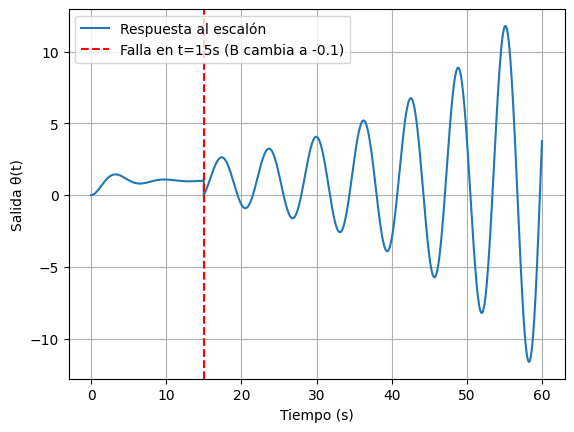

In [23]:
# Tramo 1
G1 = Gs(0.5)
T1 = ctrl.feedback(G1, 1)

t1 = np.linspace(0, 15, 1000)
t1, y1 = ctrl.step_response(T1, t1)

# Tramo 2
G2 = Gs(-0.1)
T2 = ctrl.feedback(G2, 1)

t2 = np.linspace(15, 60, 1000)
X0 = np.array([y1[-1], 0])  # Condición inicial para el tramo 2
t2, y2 = ctrl.forced_response(T2, T=t2, U=np.ones_like(t2), X0=X0)

t = np.concatenate((t1, t2))
y = np.concatenate((y1, y2))

plt.figure()
plt.plot(t, y, label='Respuesta al escalón')
plt.axvline(x=15, color='r', linestyle='--', label='Falla en t=15s (B cambia a -0.1)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida θ(t)')
plt.legend()
plt.grid()
plt.show()

SUPER INESTABLE NOOOO

### c.

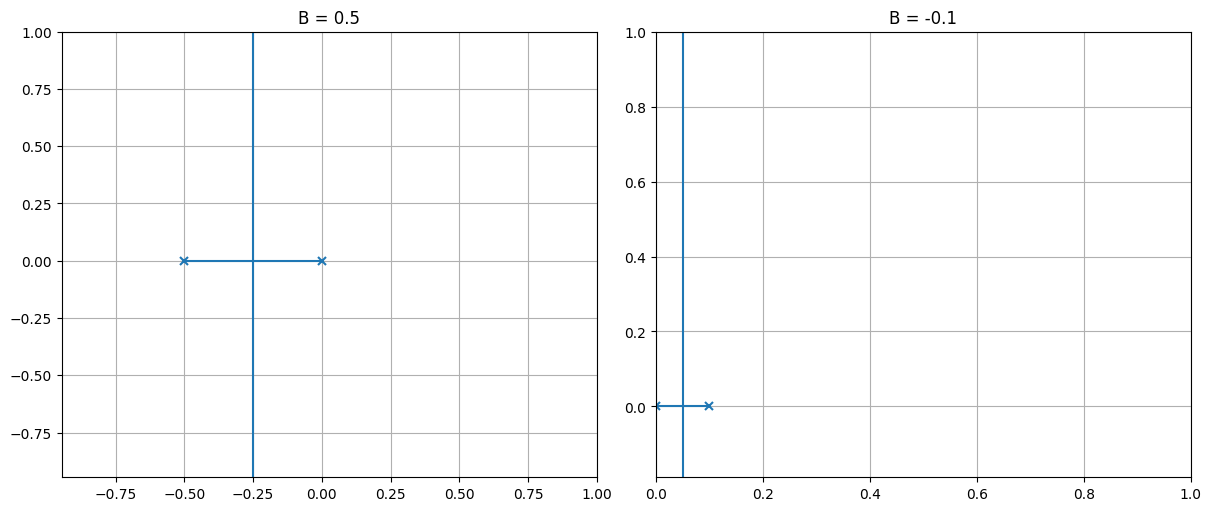

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ctrl.root_locus_plot(G1, ax=axes[0])
axes[0].set_title('B = 0.5')
axes[0].grid(True)

ctrl.root_locus_plot(G2, ax=axes[1])
axes[1].set_title('B = -0.1')
axes[1].grid(True)

plt.show()

### d.

G1 = B = 0.5
  Margen de ganancia: inf
  Margen de fase: 28.02017611933482

G2 = B = -0.1
  Margen de ganancia: inf
  Margen de fase: -5.724792592138272



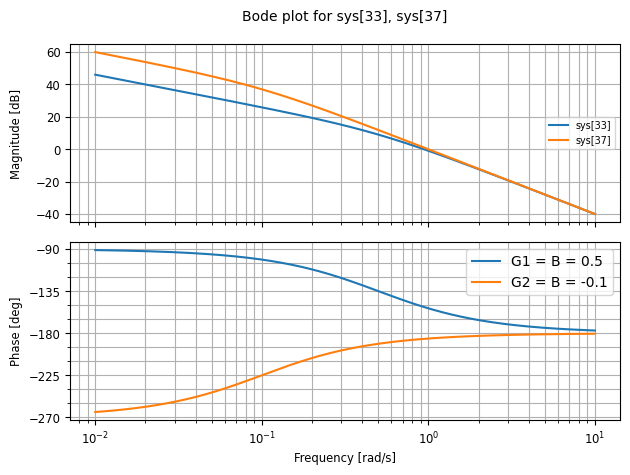

In [38]:
gm1, pm1, wg1, wp1 = ctrl.margin(G1)
gm2, pm2, wg2, wp2 = ctrl.margin(G2)

print("G1 = B = 0.5")
print(f"  Margen de ganancia: {gm1}")
print(f"  Margen de fase: {pm1}")
print()

print("G2 = B = -0.1")
print(f"  Margen de ganancia: {gm2}")
print(f"  Margen de fase: {pm2}")
print()

plt.figure()
ctrl.bode_plot([G1, G2], dB=True)
plt.legend(["G1 = B = 0.5", "G2 = B = -0.1"])
plt.show()

Margen de Fase es negativo cuando B = -0.1 entonces deberiamos usar un compensador lead para que aporte fase positiva para aumentar el margen de fase del sistema. 

# Parte B - Diseño de Compensador para Estabilidad Robusta

### Compensador Lead:

$$
C(s)=K_c\frac{s+z}{s+p}, \qquad p>z
$$